In [ ]:
# using CMPSKit, Plots, LaTeXStrings, OptimKit, KrylovKit, LinearAlgebra
using CMPSExcitations
using OrdinaryDiffEq

In [11]:
# Local densities:
n̂ = ψ̂' * ψ̂; # particle density operator
k̂ = ∂ψ̂' * ∂ψ̂; # kinetic energy density operator
û = (ψ̂')^2 * ψ̂^2; # interaction operator

H(; c, μ) = ∫(k̂ - μ * n̂ + c * û, (-Inf, +Inf));

In [84]:
# c, μ = 2., 20.
c, μ = 10., 5.

tol = 1e-10
hamiltonian = H(c=c, μ=μ)
hamiltonian_density = CMPSKit.density(hamiltonian)

Ds = [8, 16]
state = find_groundstate(Ds, hamiltonian, InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
state.Rs[1][] ./= (state.Rs[1][][1] / norm(state.Rs[1][][1])) # fix phase
ρ = expval(n̂, state)[]

println("Energy density: ", expval(hamiltonian_density, state)[], "\n Particle density: ", expval(n̂, state)[], "\n Order parameter: ", expval(ψ̂, state)[])

println("LL parameter: ", c / ρ)

Optimizing D=8


┌ Info: UniformCMPS ground state: initialization with e = 300.216648384678
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 360 iterations: f = -2.761265509087, ‖∇f‖ = 6.5046e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 8 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  4.002452 seconds (4.15 M allocations: 401.693 MiB, 1.21% gc time)
---------------
Optimizing D=16


┌ Info: UniformCMPS ground state: converged after 361 iterations: e = -2.761265509087, ‖∇e‖ = 6.5046e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127
┌ Info: UniformCMPS ground state: initialization with e = -2.761265508835
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 737 iterations: f = -2.764879048134, ‖∇f‖ = 7.5391e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 16 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
 95.014479 seconds (31.98 M allocations: 6.529 GiB, 1.23% gc time, 0.27% compilation time)
---------------
Energy density: 

┌ Info: UniformCMPS ground state: converged after 738 iterations: e = -2.764879048134, ‖∇e‖ = 7.5391e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127


-2.7648790481338588
 Particle density: 0.8739919841943586
 Order parameter: 0.4261946754477382
LL parameter: 11.44175253416992


In [85]:
nvals = 20

ps = range(0π * ρ, 2π * ρ, 30)
trivial_spectrum = zeros(ComplexF64, length(ps), nvals);
trivial_excitations = [[zeros(ComplexF64, size(state.Q[])) for _ in 1:nvals] for _ in eachindex(pts)]

Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], state, state)
    Heff = excitation_operator(hamiltonian, space)
    vals, vecs, _ = eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)
    trivial_spectrum[idx, :] .= vals[1:nvals]
    trivial_excitations[idx] .= getindex.(getindex.(vecs[1:nvals], 1))
end

┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 19 eigenvalues converged
│ * norm of residuals = (7.55e-15, 5.94e-15, 1.41e-15, 3.66e-15, 1.73e-15, 2.66e-15, 1.09e-14, 2.81e-15, 4.44e-16, 7.92e-16, 4.21e-15, 5.42e-15, 5.94e-15, 4.66e-15, 2.06e-15, 8.90e-16, 5.55e-15, 6.37e-15, 2.73e-14, 2.71e-12)
│ * number of operations = 856
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/eigsolve/arnoldi.jl:172
┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 17 eigenvalues converged
│ * norm of residuals = (1.11e-14, 8.87e-15, 9.63e-16, 1.17e-14, 1.27e-15, 6.81e-15, 9.97e-15, 1.71e-15, 5.46e-15, 2.27e-15, 8.06e-15, 1.96e-14, 5.15e-15, 2.75e-15, 1.28e-14, 7.39e-15, 1.69e-14, 1.17e-11, 1.10e-08, 9.27e-08)
│ * number of operations = 921
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/eigsolve/arnoldi.jl:172
┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 16 eigenvalues

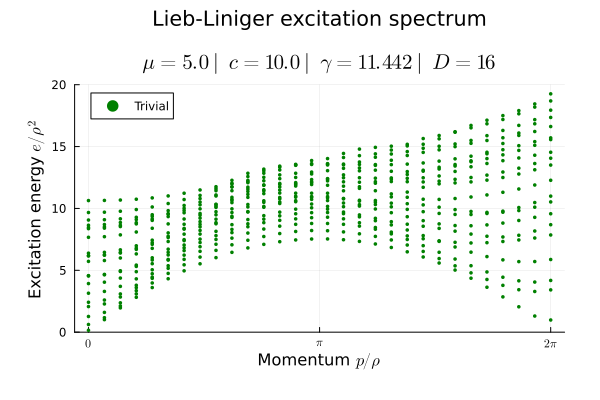

In [88]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, ylims=[0, 20], lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:green, markerstrokewidth=0)
plot!(xtick=pitick(0, 4π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)

In [116]:
nvals = 10
pts = range(-π * ρ, π * ρ, 31)
topological_spectrum = zeros(ComplexF64, length(pts), nvals);
topological_excitations = [[zeros(ComplexF64, size(state.Q[])) for _ in 1:nvals] for _ in eachindex(pts)]
u1charges = zeros(ComplexF64, length(pts), nvals)

ρr = rightenv(state)[1][]
theta = π
state = InfiniteCMPS(Constant(ComplexF64.(state.Q[])), Constant(ComplexF64.(state.Rs[1][])))
state_alt = InfiniteCMPS(state.Q, exp(1im * theta) * state.Rs[1])

Threads.@threads for idx in eachindex(pts)
    space = InfiniteCMPSExcitationSpace(pts[idx], state, state_alt)
    Heff = excitation_operator(hamiltonian, space)
    vals, vecs, _ = eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)
    topological_spectrum[idx, :] .= vals[1:nvals]
    topological_excitations[idx] .= getindex.(getindex.(vecs[1:nvals], 1))

    for (i, W) in enumerate(topological_excitations[idx])
        # ∫⟨ρ⟩ - ⟨ρ₀⟩ = N -> particle/hole charge
        Hψ = excitation_operator(∫(ψ̂' * ψ̂, (-Inf, Inf)), space)
        ψW = Hψ((Constant(W),))[1][]
        u1charges[idx, i] = tr(ψW * ρr * W')
    end
    # println("Finished $idx - $(pts[idx])")
end

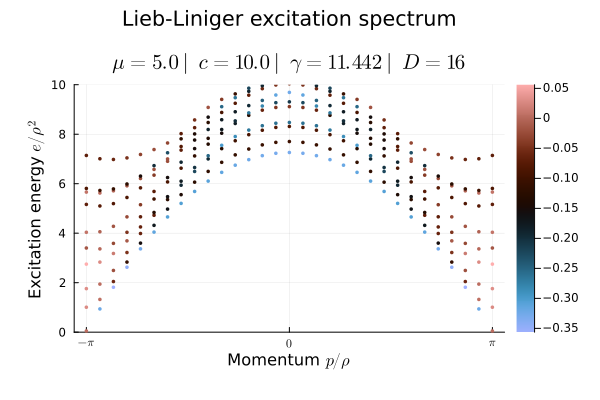

In [119]:
scatter(pts ./ ρ, real.(topological_spectrum) ./ ρ^2, ylims=[0, 10], lab=permutedims([""; fill("", nvals - 1)]), ms=2., marker_z=real.(u1charges), markerstrokewidth=0, colorbar=true, c=:berlin)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)

In [120]:
function apply_expT(Q, R, ρ₀, xi, xf; side=:R)
    if side == :R
        function dρRdx!(dρR, ρR, (Q, R), x)
            dρR .= (Q * ρR + ρR * Q' + R * ρR * R')
        end

        prob = ODEProblem(dρRdx!, ρ₀, (xi, xf), (Q, R))
        return solve(prob, Tsit5())

    elseif side == :L
        function dρLdx!(dρL, ρL, (Q, R), x)
            dρL .= (ρL * Q + Q' * ρL + R' * ρL * R)
        end

        prob = ODEProblem(dρLdx!, ρ₀, (xi, xf), (Q, R))
        return solve(prob)
    else
        throw(DomainError(side, "Side must be either :L or :R."))
    end
end

function soliton_density(state1, state2, W1, W2, dist, x, N)
    yl = range(x - dist, x, N)[1:end-1]
    yr = range(x, x + dist, N)[2:end]
    ys = append!(collect(yl), [x], collect(yr))

    l1, r1, _, _ = environments!(state1)
    l2, r2, _, _ = environments!(state2)

    Q1, R1 = state1.Q[], state1.Rs[1][]
    Q2, R2 = state2.Q[], state2.Rs[1][]

    # left, y < x
    ρRs = apply_expT(Q1, R1, W1 * r2[] * W2', 0.0, dist, side=:R).(x .- yl)
    densities = tr.(l1[] * R1 * ρR * R1' for ρR in ρRs)

    # centre, y = x
    push!(densities, tr(l1[] * W1 * r2[] * W2'))

    # right, y > x
    ρRs = apply_expT(Q2, R2, R2 * r2[] * R2', 0.0, dist, side=:R).(yr .- x)
    append!(densities, tr.(l1[] * W1 * ρR * W2' for ρR in ρRs))

    return ys, densities
end

soliton_density (generic function with 2 methods)

  0.217600 seconds (37.32 k allocations: 29.036 MiB, 3.22% gc time)


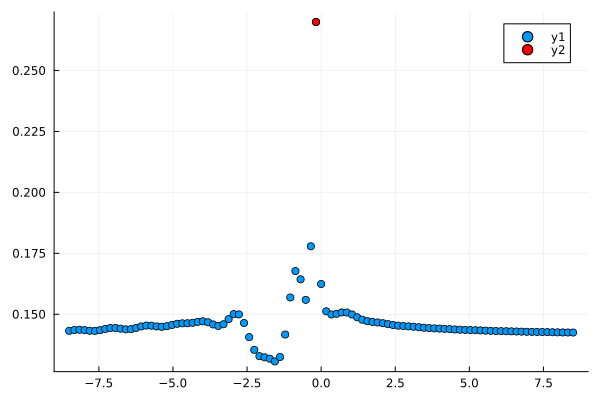

In [ ]:
W1 = trivial_excitations[10][1]
@time xs1, densities1 = soliton_density(state, state, W1, W1, 8.5, 0., 50)
scatter(xs1, real.(densities1))
scatter!([xs1[(length(xs1)-1)÷2]], [real(densities1[(length(xs1)-1)÷2])], c=:red)
plot!(ylims=[0, Inf])

  0.462017 seconds (24.31 k allocations: 30.895 MiB, 1.49% gc time)


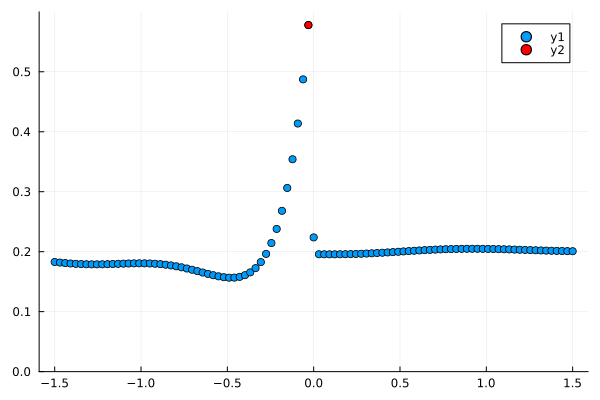

In [ ]:
W2 = topological_excitations[end][1]
@time xs2, densities2 = soliton_density(state, state_alt, W2, W2, 1.5, 0., 50)
scatter(xs2, real.(densities2))
scatter!([xs2[(length(xs2)-1)÷2]], [real(densities2[(length(xs2)-1)÷2])], c=:red)
plot!(ylims=[0, 0.6])

In [41]:
densities = soliton_density(state, state_alt, W1, W2, 1.5, 0., 50)[2] + soliton_density(state, state_alt, W2, W1, 1.5, 0., 50)[2] + soliton_density(state, state_alt, W1, W1, 1.5, 0., 50)[2] + soliton_density(state, state_alt, W2, W2, 1.5, 0., 50)[2];

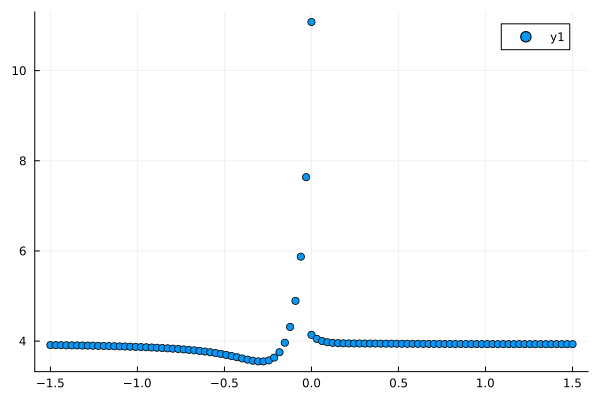

In [45]:
scatter(xs1, real.(densities))

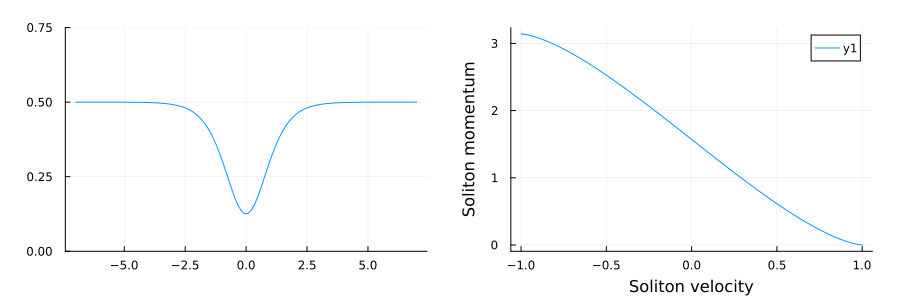

In [163]:
let
    m = 1
    ρ₀ = μ / c
    vc = sqrt(c * ρ₀ / m)
    v = vc * 0.5
    # x in units of healing length
    mf_soliton(x) = sqrt(ρ₀) * (1im * v / vc + sqrt(1 - v^2 / vc^2) * tanh(x * sqrt(1 - v^2 / vc^2)))

    xmax = 7
    xs = range(-xmax, xmax, 100)
    p1 = plot(xs, abs2.(mf_soliton.(xs)), ylim=[0, ρ₀ * 1.5], lab="")
    p2 = plot(v -> 2 * ρ₀ * (acos(v) - v * sqrt(1 - v^2)), range(-1, 1, 50), xlabel="Soliton velocity", ylabel="Soliton momentum")
    plot(p1, p2, layout=(1, 2), size=(900, 300), margins=5Plots.mm)
end